In [1]:
import seaborn as sns

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 

import h5py
from scipy.integrate import simpson
from scipy.optimize import curve_fit
from matplotlib.ticker import AutoMinorLocator

plt.rc('axes', linewidth=3, labelsize=22)
plt.rc('xtick', labelsize=22)  # fontsize of the x tick labels
plt.rc('ytick', labelsize=22)  # fontsize of the y tick labels
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'  # Axis labels
plt.rcParams['axes.titleweight'] = 'bold' 

sns.set_theme(font_scale=2.25)
sns.set_style("white")

In [2]:

def apply_ax_format(ax,xlabel="",ylabel="",title="",legend=False,inset=False):
    if not inset:
        ax.spines['bottom'].set_color('0')
        ax.spines['top'].set_color('1')
        ax.spines['right'].set_color('1')
        ax.spines['left'].set_color('0')
    ax.tick_params(which="both",direction='out', width=3, bottom=True, left=True)
    ax.grid(False)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    if legend:
        plt.setp(ax.get_legend().get_texts(), fontsize='22') # for legend text
        plt.setp(ax.get_legend().get_title(), fontsize='22') # for legend title



In [3]:


# Fit the resolution data to a polynomial for extrapolation
def poly_func(x, a, b, c):
    return a * x**2 + b * x + c

# Create a function to get resolution for any energy
def get_resolution(e,popt):
    return np.maximum(poly_func(e, *popt), 1e-10)  # Ensure non-zero resolution


# Perform Gaussian broadening using convolution with energy-dependent widths
def gaussian_broadening(dos, energy, sigmas):
    broadened_dos = np.zeros_like(dos)
    for i in range(len(energy)):
        # Create a Gaussian kernel centered at each energy point with width sigmas[i]
        kernel = np.exp(-0.5 * ((energy - energy[i]) / sigmas[i])**2)
        kernel /= simpson(kernel, energy)  # Normalize the kernel to preserve area
        broadened_dos += dos[i] * kernel  # Convolve DOS with Gaussian kernel
    return broadened_dos

def apply_gaussian_broadening(dos_data,metric='dos total (nm2/ps)',unit_cell_atoms=1):
    energy = dos_data['Energy Transfer (meV)'].values
    dos = dos_data[metric].values

    resolution_data = pd.read_csv('../data/resolution.csv')
    res_energy = resolution_data['Energy (meV)'].values
    resolution = resolution_data['Resolution'].values
    popt, _ = curve_fit(poly_func, res_energy, resolution)
    
    # Create an array of sigmas for Gaussian broadening based on the resolution function
    sigmas = get_resolution(energy,popt) / np.sqrt(8 * np.log(2))  # Convert FWHM to sigma


    broadened_dos = gaussian_broadening(dos, energy, sigmas)

    # Area normalize both original and broadened DOS
    original_area = simpson(dos, energy)
    broadened_area = simpson(broadened_dos, energy)

    dos_normalized = dos / original_area
    #dos_normalized-=dos_normalized[0]
    broadened_dos_normalized = broadened_dos / broadened_area
    return dos_normalized #3*unit_cell_atoms*broadened_dos_normalized

In [4]:
results_directory=dict()
for temperature in np.arange(100,450,50):
    for subset in ["H2O","SiO2","Total"]:
        results_directory["../results/gromacs/pore/4nm/H2O/results_720/%d/%s/out_dos.h5" % (temperature,subset)]=(temperature,subset)

df_list=list()

min_energy=0
max_energy=1500

for pdos_file,(temperature,subset) in results_directory.items():
    print(pdos_file)
    h5file=h5py.File(pdos_file)
    data_dict=dict()
    omega_shape=h5file["omega"][:].shape
    for k in h5file.keys():
        data_array=h5file[k][:]
        if data_array.shape != omega_shape or "_0" in k:
            continue
        units=h5file[k].attrs['units']
        data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array
    h5file.close()
    df_tmp=pd.DataFrame(data_dict).query("%f < `omega (rad/ps)` and `omega (rad/ps)` < %f"%(min_energy/0.6582,max_energy/0.6582))
    df_tmp["Energy Transfer (meV)"]=df_tmp["omega (rad/ps)"]*0.6582
    df_tmp["Normalized Count"]=apply_gaussian_broadening(df_tmp)
    df_tmp["Max Normalized Count"]=df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
    df_tmp["Temperature (K)"]=temperature
    df_tmp["Subset"]=subset
    df_list.append(df_tmp)
        
df_dos_mdanse=pd.concat(df_list,ignore_index=True)
df_dos_mdanse

../results/gromacs/pore/4nm/H2O/results_720/100/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/100/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/100/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/150/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/150/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/150/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/200/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/200/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/200/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/250/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/250/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/250/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/300/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/300/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/300/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_

,dos H (nm2/ps),dos M (nm2/ps),dos O (nm2/ps),dos total (nm2/ps),omega (rad/ps),omega window (au),time window (au),Energy Transfer (meV),Normalized Count,Max Normalized Count,Temperature (K),Subset,dos Si (nm2/ps)
0,0.000014,0.000010,1.033359e-05,0.000014,0.062835,2.501685,9.999875e-01,0.041358,0.000074,0.003310,100,H2O,NaN
1,0.000014,0.000011,1.044359e-05,0.000014,0.125670,2.486913,9.999500e-01,0.082716,0.000074,0.003343,100,H2O,NaN
2,0.000014,0.000011,1.062712e-05,0.000014,0.188505,2.462486,9.998875e-01,0.124074,0.000076,0.003397,100,H2O,NaN
3,0.000014,0.000011,1.088446e-05,0.000014,0.251340,2.428692,9.998000e-01,0.165432,0.000077,0.003474,100,H2O,NaN
4,0.000015,0.000011,1.121602e-05,0.000015,0.314175,2.385922,9.996875e-01,0.206790,0.000080,0.003572,100,H2O,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
209974,0.000022,NaN,2.523867e-08,0.000021,628.035787,0.000000,3.716009e-17,413.373155,0.000033,0.001578,400,Total,6.103163e-08
209975,0.000022,NaN,2.524778e-08,0.000021,628.098622,0.000000,2.741944e-18,413.414513,0.000033,0.001578,400,Total,6.105807e-08
209976,0.000022,NaN,2.525467e-08,0.000021,628.161457,0.000000,4.071618e-17,413.455871,0.000033,0.001579,400,Total,6.107806e-08
209977,0.000022,NaN,2.525930e-08,0.000021,628.224292,0.000000,8.530829e-18,413.497229,0.000033,0.001579,400,Total,6.109147e-08


In [12]:
df_PPR=pd.read_csv("../results/gromacs/pore/4nm/H2O/results_720/df_PPR.csv")
df_f_H2O=pd.read_csv("../results/gromacs/pore/4nm/H2O/results_720/df_f_H2O.csv")
df_f_H2O

,Unnamed: 0,Energy Transfer (meV),f_H2O,1/N_H2O,1/N_total,Temperature (K)
0,0,0.041358,0.396754,0.001389,0.000087,100
1,1,0.082716,0.394234,0.001389,0.000087,100
2,2,0.124074,0.390190,0.001389,0.000087,100
3,3,0.165432,0.384830,0.001389,0.000087,100
4,4,0.206790,0.378404,0.001389,0.000087,100
...,...,...,...,...,...,...
67692,67692,399.807733,0.010980,0.001389,0.000087,400
67693,67693,399.849091,0.011050,0.001389,0.000087,400
67694,67694,399.890449,0.011130,0.001389,0.000087,400
67695,67695,399.931807,0.011220,0.001389,0.000087,400


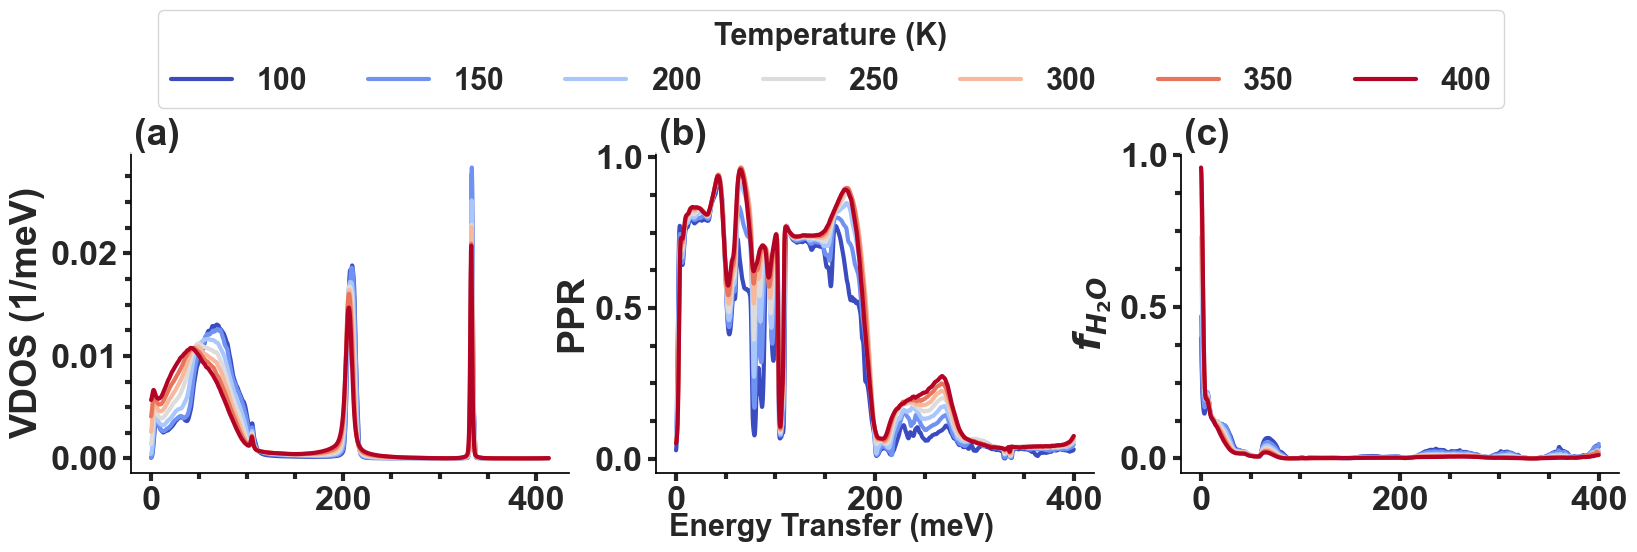

In [20]:
fig, axs = plt.subplots(ncols=3,figsize=(7*2.5,4))
labx=0.00625
laby=1.025
index=["(%s)"%x for x in list("abcdefghijkl")]

ax=axs[0]
ax.text(labx, laby, index[0],weight='bold' ,transform=ax.transAxes)

sns.lineplot(data=df_dos_mdanse.query("Subset == 'Total' ")
            ,y="Normalized Count"
            ,x="Energy Transfer (meV)"
            ,ax=ax
            ,lw=3
            ,palette="coolwarm"
            ,hue="Temperature (K)"
       )

apply_ax_format(ax,ylabel="VDOS (1/meV)")

legend_y=1.25
sns.move_legend(ax,'lower center',bbox_to_anchor=(0.5,0.975),ncol=7,bbox_transform=fig.transFigure,fontsize=22,title_fontsize=22)

ax=axs[1]
ax.text(labx, laby, index[1],weight='bold' ,transform=ax.transAxes)

sns.lineplot(data=df_PPR
            , y='PPR'
            , x='Energy Transfer (meV)'
            ,ax=ax
           ,hue='Temperature (K)'
           ,lw=3
           ,palette="coolwarm"
           ,legend=False
                )

apply_ax_format(ax,ylabel="PPR")

ax=axs[2]
ax.text(labx, laby, index[2],weight='bold' ,transform=ax.transAxes)

sns.lineplot(data=df_f_H2O
            , y='f_H2O'
            , x='Energy Transfer (meV)'
            ,ax=ax
           ,hue='Temperature (K)'
           ,lw=3
           ,palette="coolwarm"
           ,legend=False
                )

apply_ax_format(ax,ylabel="$f_{H_2O}$")

ax.text(0.5, 0.0, "Energy Transfer (meV)",weight='bold' ,transform=fig.transFigure,ha='center',va='top',fontsize=22)         


plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.95, 
                    top=0.9, 
                    wspace=0.2, 
                    hspace=0.
                   )

plt.savefig("../figures/fig12.pdf", pad_inches=0.2,bbox_inches="tight")